# 10 — LightGBM + Sentimiento de Noticias

Extiende el modelo LightGBM incorporando **señales de sentimiento** extraídas de los headlines.

### Estrategia de sentimiento (sin LLM, reglas léxicas)
Los headlines tienen patrones muy claros y repetibles:

| Patrón | Sentimiento |
|--------|-------------|
| surge, rally, boost, record high, growth, supports, sustainable | +1 |
| decline, drop, recession, fears, weighs, volatility spikes | -1 |
| central bank policy shift, energy prices impact, analysts forecast | 0 (neutro) |

Features generadas por día:
- `sent_global`: sentimiento medio de todas las noticias del día
- `sent_<Index_X>`: sentimiento de noticias que mencionan ese índice
- `sent_roll5`, `sent_roll10`: rolling de sentimiento global (momentum de narrativa)
- `n_news`: número de noticias del día (proxy de actividad informativa)

In [11]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from utils import (
    load_data, compute_rmse, make_submission, train_val_split,
    create_lag_features, add_calendar_features, add_log_returns, INDEX_COLS
)

data       = load_data()
train_full = data['train_indices'][INDEX_COLS]
test_dates = data['test_dates'].index
train, val = train_val_split(train_full, val_size=252)

news_train = data['train_news']
news_test  = data['test_news']
news_all   = pd.concat([news_train, news_test]).sort_index()

LAGS    = (1, 2, 3, 5, 10, 20, 60)
WINDOWS = (5, 10, 20, 60)

print(f'Train: {train.shape}  |  Val: {val.shape}  |  Test: {len(test_dates)} dias')
print(f'News train: {news_train.shape}  |  News test: {news_test.shape}')

Train: (2095, 6)  |  Val: (252, 6)  |  Test: 262 dias
News train: (971, 1)  |  News test: (113, 1)


## 1 — Extracción de sentimiento

In [12]:
POSITIVE = [
    # momentum alcista
    'surge', 'surges', 'surging', 'rally', 'rallies', 'rallying',
    'boost', 'boosted', 'boosting', 'lifts', 'lifted',
    'record high', 'all-time high', 'breaks record', 'new high',
    'growth', 'grows', 'growing', 'expand', 'expansion',
    'supports', 'supported', 'sustainable', 'recover', 'recovery',
    'rebound', 'rebounds', 'forecast growth', 'outperform',
    'strong', 'strength', 'gains', 'gained', 'advance', 'advances',
    'rises', 'rises to', 'climbs', 'jumped', 'jumps', 'soars', 'soaring',
    'optimism', 'optimistic', 'bullish', 'beat', 'beats expectations',
    'upgrade', 'upgrades', 'positive outlook', 'higher',
]
NEGATIVE = [
    # momentum bajista
    'decline', 'declines', 'declining', 'drop', 'drops', 'dropped',
    'recession', 'recessionary', 'fears', 'fear', 'concern', 'concerns',
    'weighs', 'drags', 'drag', 'pressure', 'pressures', 'pressured',
    'volatility spikes', 'spikes', 'uncertainty', 'uncertain',
    'slows', 'slowdown', 'slow growth', 'contraction', 'contracts',
    'falls', 'fell', 'tumbles', 'tumbled', 'plunges', 'plunged',
    'crash', 'crashes', 'selloff', 'sell-off', 'correction',
    'downgrade', 'downgrades', 'weak', 'weakness', 'worries', 'worry',
    'miss', 'misses expectations', 'below expectations', 'lower',
    'crisis', 'default', 'contagion', 'risk-off', 'bearish',
    'inflation', 'rate hike', 'tightening', 'hawkish',
]

def score_headline(text):
    t = str(text).lower()
    pos = sum(1 for p in POSITIVE if p in t)
    neg = sum(1 for n in NEGATIVE if n in t)
    if pos > neg: return 1.0
    if neg > pos: return -1.0
    return 0.0

def extract_mentioned_index(text):
    t = str(text)
    return [idx for idx in INDEX_COLS if idx in t]


def build_sentiment_features(news_df, all_dates):
    news_df = news_df.copy()
    news_df.index = pd.to_datetime(news_df.index)
    news_df['score']    = news_df['Headline'].apply(score_headline)
    news_df['mentions'] = news_df['Headline'].apply(extract_mentioned_index)

    global_sent = news_df.groupby(news_df.index)['score'].mean().rename('sent_global')
    n_news      = news_df.groupby(news_df.index).size().rename('n_news')

    rows = []
    for date, grp in news_df.groupby(news_df.index):
        row = {'Date': date}
        for idx in INDEX_COLS:
            mask = grp['mentions'].apply(lambda m: idx in m)
            row[f'sent_{idx}'] = grp.loc[mask, 'score'].mean() if mask.any() else 0.0
        rows.append(row)

    sent_per_idx = pd.DataFrame(rows).set_index('Date')

    result = pd.concat([global_sent, n_news, sent_per_idx], axis=1)
    result = result.reindex(all_dates).fillna(0)

    # Rolling momentum (shift(1) evita leakage — las noticias de D no están disponibles hasta D)
    result['sent_roll5']  = result['sent_global'].shift(1).rolling(5,  min_periods=1).mean()
    result['sent_roll10'] = result['sent_global'].shift(1).rolling(10, min_periods=1).mean()
    result['sent_roll20'] = result['sent_global'].shift(1).rolling(20, min_periods=1).mean()

    return result


all_dates  = train_full.index.union(test_dates)
sent_feats = build_sentiment_features(news_all, all_dates)

print('Sentiment features shape:', sent_feats.shape)
print(sent_feats.head(3))
print()
print('Distribucion de sentimiento global:')
print(sent_feats['sent_global'].value_counts())
nonzero_pct = (sent_feats['sent_global'] != 0).mean() * 100
print(f'\nDias con sentimiento no-nulo: {nonzero_pct:.1f}%')

Sentiment features shape: (2609, 11)
            sent_global  n_news  sent_Index_A  sent_Index_B  sent_Index_C  \
2015-01-01          0.0     0.0           0.0           0.0           0.0   
2015-01-02          1.0     1.0           0.0           0.0           1.0   
2015-01-05          0.0     0.0           0.0           0.0           0.0   

            sent_Index_D  sent_Index_E  sent_Index_F  sent_roll5  sent_roll10  \
2015-01-01           0.0           0.0           0.0         NaN          NaN   
2015-01-02           0.0           0.0           0.0         0.0          0.0   
2015-01-05           0.0           0.0           0.0         0.5          0.5   

            sent_roll20  
2015-01-01          NaN  
2015-01-02          0.0  
2015-01-05          0.5  

Distribucion de sentimiento global:
sent_global
 0.0    1731
 1.0     550
-1.0     328
Name: count, dtype: int64

Dias con sentimiento no-nulo: 33.7%


## 2 — Visualizar sentimiento vs índices

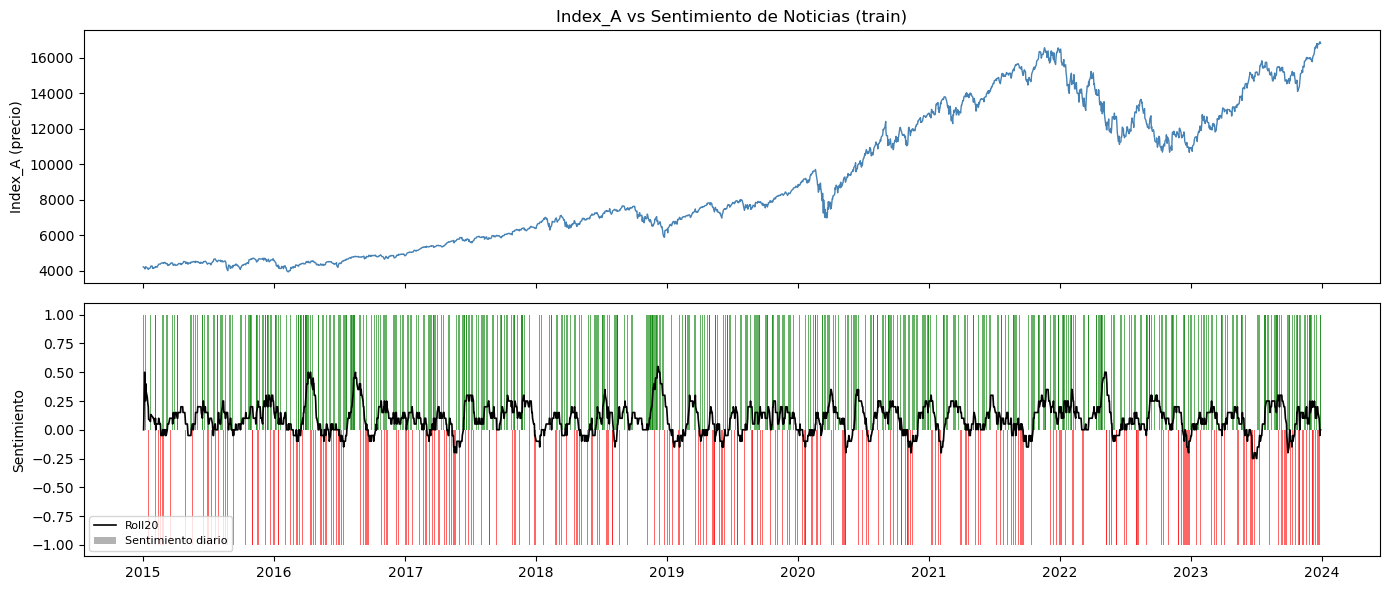

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Precio Index_A (NASDAQ proxy)
axes[0].plot(train_full.index, train_full['Index_A'], color='steelblue', lw=1)
axes[0].set_ylabel('Index_A (precio)')
axes[0].set_title('Index_A vs Sentimiento de Noticias (train)')

# Sentimiento rolling 20 dias
sent_train = sent_feats.reindex(train_full.index)
axes[1].bar(sent_train.index, sent_train['sent_global'], color=[
    'green' if v > 0 else ('red' if v < 0 else 'gray')
    for v in sent_train['sent_global']], width=3, alpha=0.6, label='Sentimiento diario')
axes[1].plot(sent_train.index, sent_train['sent_roll20'], color='black', lw=1.2, label='Roll20')
axes[1].set_ylabel('Sentimiento')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('sentiment_vs_price.png', dpi=100)
plt.show()

## 3 — Feature engineering con sentimiento

In [14]:
SENT_COLS = list(sent_feats.columns)

# Columnas que necesitan shift(1) en build_features (son el valor del día D, no D-1)
# sent_roll* ya incorporan shift(1) internamente en build_sentiment_features,
# así que NO se les aplica shift adicional aquí.
SENT_COLS_TO_SHIFT   = ['sent_global', 'n_news'] + [f'sent_{idx}' for idx in INDEX_COLS]
SENT_COLS_PRELAGGED  = ['sent_roll5', 'sent_roll10', 'sent_roll20']

def build_features_sentiment(indices, sent_all):
    df = indices[INDEX_COLS].copy()
    df = add_log_returns(df)
    df = create_lag_features(df, lags=LAGS, windows=WINDOWS)
    df = add_calendar_features(df)

    sent_aligned = sent_all[SENT_COLS].reindex(df.index).fillna(0)

    # Columnas del día D → shift(1) para usar valor de ayer
    for col in SENT_COLS_TO_SHIFT:
        df[f'news_{col}'] = sent_aligned[col].shift(1)

    # Columnas ya pre-shifteadas en build_sentiment_features → sin shift adicional
    for col in SENT_COLS_PRELAGGED:
        df[f'news_{col}'] = sent_aligned[col]

    return df


def prepare_xy(feats, targets):
    rename = {c: f'__t_{c}' for c in INDEX_COLS}
    combined = pd.concat([feats, targets.rename(columns=rename)], axis=1).dropna()
    tgt_cols = list(rename.values())
    return combined.drop(columns=tgt_cols).values, combined[tgt_cols].values, list(combined.drop(columns=tgt_cols).columns)


feats_tr = build_features_sentiment(train, sent_feats)
X_tr, y_tr, feature_names = prepare_xy(feats_tr, train)
print(f'Feature matrix train: {X_tr.shape}')
news_features = [f for f in feature_names if f.startswith('news_')]
print(f'Features de sentimiento: {len(news_features)} -> {news_features}')

Feature matrix train: (2034, 206)
Features de sentimiento: 11 -> ['news_sent_global', 'news_n_news', 'news_sent_Index_A', 'news_sent_Index_B', 'news_sent_Index_C', 'news_sent_Index_D', 'news_sent_Index_E', 'news_sent_Index_F', 'news_sent_roll5', 'news_sent_roll10', 'news_sent_roll20']


## 4 — Entrenamiento

In [15]:
def train_lgbm(X, y, n_estimators=500):
    try:
        import lightgbm as lgb
        models = []
        for i, col in enumerate(INDEX_COLS):
            m = lgb.LGBMRegressor(
                n_estimators=n_estimators, learning_rate=0.05,
                num_leaves=63, subsample=0.8, colsample_bytree=0.8, verbose=-1
            )
            m.fit(X, y[:, i])
            models.append(m)
        return models, 'lgbm'
    except ImportError:
        pass
    from sklearn.ensemble import GradientBoostingRegressor
    models = [GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                        max_depth=5, subsample=0.8
                                        ).fit(X, y[:, i]) for i in range(y.shape[1])]
    return models, 'sklearn_gbr'


models_val, lib = train_lgbm(X_tr, y_tr)
print(f'Modelos entrenados ({lib})')

Modelos entrenados (sklearn_gbr)


## 5 — Predicción autorregresiva

In [16]:
def autoreg_predict_sentiment(models, history, dates, sent_all, feature_names):
    history = history[INDEX_COLS].copy()
    preds = []
    for date in dates:
        feats = build_features_sentiment(history, sent_all)
        row = feats.dropna().iloc[[-1]]
        for c in feature_names:
            if c not in row.columns:
                row[c] = 0.0
        row = row[feature_names]
        y_hat = np.array([m.predict(row.values)[0] for m in models])
        preds.append(y_hat)
        new_row = pd.DataFrame([y_hat], index=[date], columns=INDEX_COLS)
        history = pd.concat([history, new_row])
    return pd.DataFrame(preds, index=dates, columns=INDEX_COLS)

## 6 — Validación local

In [17]:
print('Prediciendo en validacion (252 dias)...')
pred_val = autoreg_predict_sentiment(models_val, train, val.index, sent_feats, feature_names)
rmse = compute_rmse(val, pred_val)
print(f'[SentimentLGBM] RMSE validacion = {rmse:,.2f}')
per = np.sqrt(((val.values - pred_val.values) ** 2).mean(axis=0))
for col, r in zip(INDEX_COLS, per):
    print(f'  {col}: {r:,.2f}')
print()
print('Referencia LightGBM sin sentimiento (nb 03): ~3.279')

Prediciendo en validacion (252 dias)...
[SentimentLGBM] RMSE validacion = 3,283.75
  Index_A: 3,225.03
  Index_B: 398.63
  Index_C: 0.74
  Index_D: 3,460.69
  Index_E: 9.94
  Index_F: 12,607.46

Referencia LightGBM sin sentimiento (nb 03): ~3.279


## 7 — Importancia de features de sentimiento

In [18]:
if lib == 'lgbm':
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, m, col in zip(axes.flatten(), models_val, INDEX_COLS):
        imp = pd.Series(m.feature_importances_, index=feature_names)
        news_imp = imp[[f for f in feature_names if f.startswith('news_')]].sort_values(ascending=False)
        news_imp.plot(kind='bar', ax=ax, color='darkorange')
        ax.set_title(f'{col} — importancia features sentimiento')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('sentiment_feature_importance.png', dpi=100)
    plt.show()
else:
    print('Importancia de features disponible solo con LightGBM nativo (pip install lightgbm)')

Importancia de features disponible solo con LightGBM nativo (pip install lightgbm)


## 8 — Reentrenar con todos los datos y generar submission

In [ ]:
print('Reentrenando con train completo...')
feats_full = build_features_sentiment(train_full, sent_feats)
X_full, y_full, fn_full = prepare_xy(feats_full, train_full)
models_full, _ = train_lgbm(X_full, y_full)

print('Prediciendo test (262 dias autorregresivos)...')
pred_test = autoreg_predict_sentiment(models_full, train_full, test_dates, sent_feats, fn_full)
make_submission(pred_test, 'submission_10_sentiment_lgbm.csv')
pred_test.head()

Reentrenando con train completo...


## 9 — Comparativa: sentimiento vs base

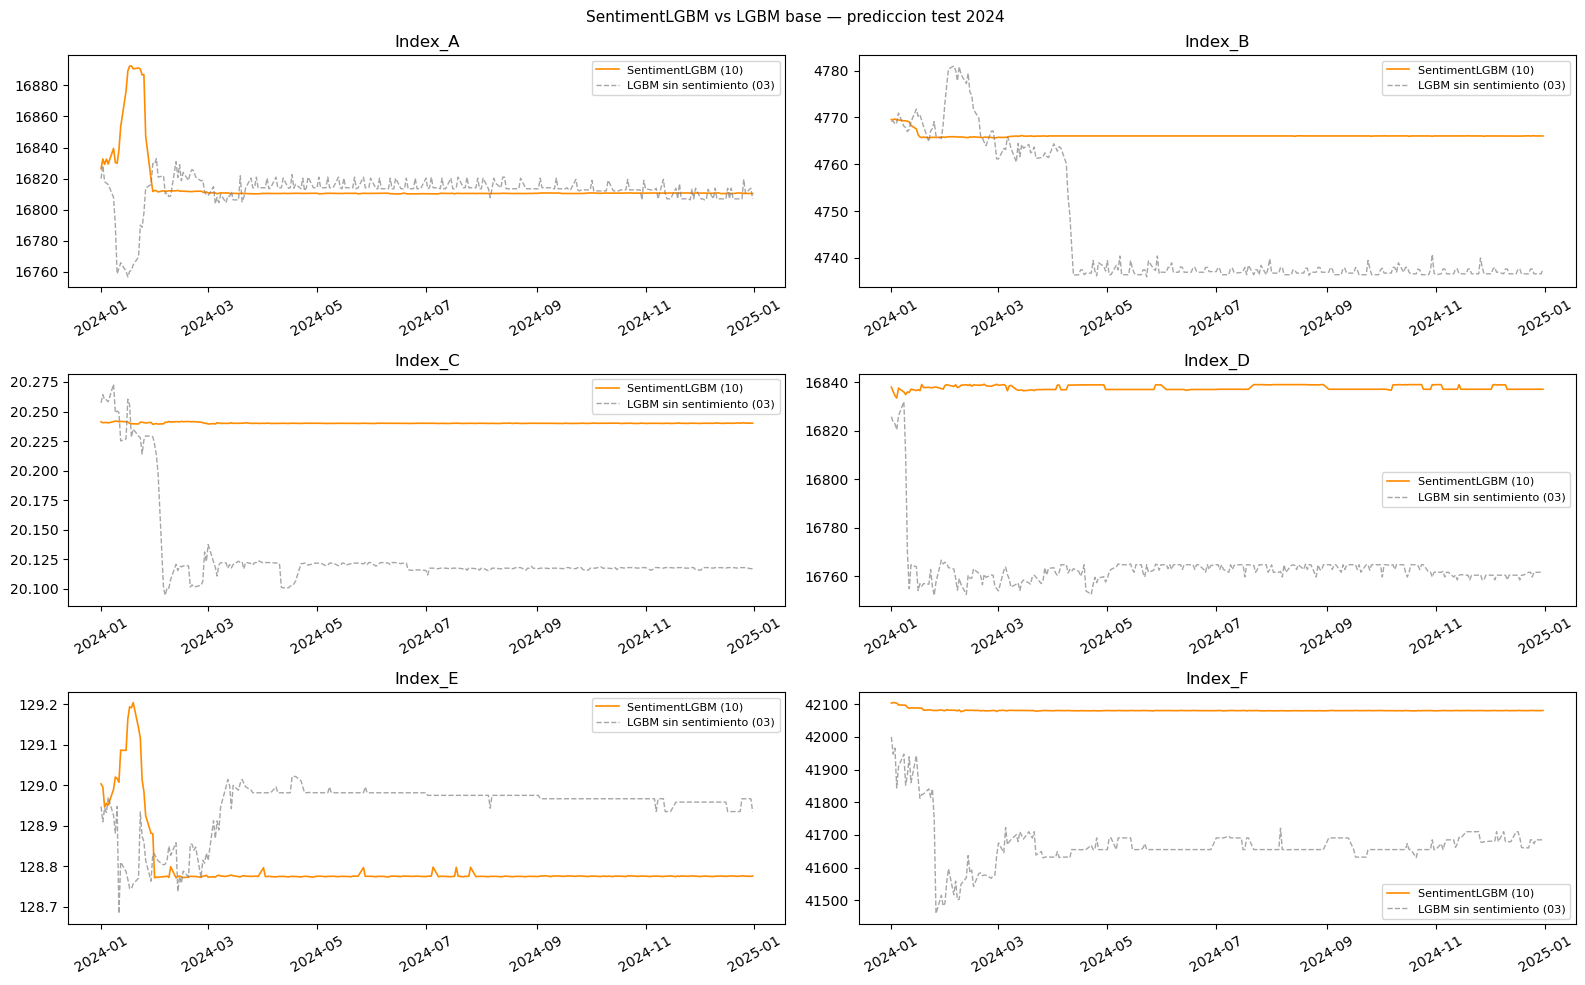

In [ ]:
import os
sub03_path = os.path.join('submissions', 'submission_03_lgbm.csv')
if os.path.exists(sub03_path):
    sub03 = pd.read_csv(sub03_path, parse_dates=[0], index_col=0).reindex(test_dates)[INDEX_COLS]

    fig, axes = plt.subplots(3, 2, figsize=(16, 10))
    for ax, col in zip(axes.flatten(), INDEX_COLS):
        ax.plot(test_dates, pred_test[col], label='SentimentLGBM (10)', color='darkorange', lw=1.2)
        ax.plot(test_dates, sub03[col], label='LGBM sin sentimiento (03)', color='gray',
                lw=1.0, linestyle='--', alpha=0.7)
        ax.set_title(col)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('SentimentLGBM vs LGBM base — prediccion test 2024', fontsize=11)
    plt.tight_layout()
    plt.savefig('sentiment_lgbm_vs_base.png', dpi=100)
    plt.show()
else:
    print('Ejecuta primero 03_LightGBM.ipynb para tener la referencia')